### Importing Libraries





In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Data Set

In [3]:
df=pd.read_csv(r"C:\Users\hp\Downloads\web_data.csv")

### Checking Data

In [4]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


### Changing Unwanted Column Names

In [5]:
df.columns=df.iloc[0]
df=df.drop(index=0).reset_index(drop=True)
df.columns=["Channel group","Datehour","Users","Session","Engaged Session","Average engagement time per session","Engaged session per user","Events per session","Engagement rate","Event count"]
df.head()


,Channel group,Datehour,Users,Session,Engaged Session,Average engagement time per session,Engaged session per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


### Basic Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Channel group                        3182 non-null   str  
 1   Datehour                             3182 non-null   str  
 2   Users                                3182 non-null   str  
 3   Session                              3182 non-null   str  
 4   Engaged Session                      3182 non-null   str  
 5   Average engagement time per session  3182 non-null   str  
 6   Engaged session per user             3182 non-null   str  
 7   Events per session                   3182 non-null   str  
 8   Engagement rate                      3182 non-null   str  
 9   Event count                          3182 non-null   str  
dtypes: str(10)
memory usage: 506.9 KB


In [7]:
df.isna().sum()

Channel group                          0
Datehour                               0
Users                                  0
Session                                0
Engaged Session                        0
Average engagement time per session    0
Engaged session per user               0
Events per session                     0
Engagement rate                        0
Event count                            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

### Changing  Data Types

In [9]:
df["Datehour"]=pd.to_datetime(df["Datehour"],format="%Y%m%d%H",errors="coerce")

In [10]:
num_col=df.columns.drop(["Channel group","Datehour"])
df[num_col]=df[num_col].apply(pd.to_numeric,errors="coerce")
df["Hour"]=df["Datehour"].dt.hour

In [11]:
df.head()

,Channel group,Datehour,Users,Session,Engaged Session,Average engagement time per session,Engaged session per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [12]:
df.dtypes

Channel group                                     str
Datehour                               datetime64[us]
Users                                           int64
Session                                         int64
Engaged Session                                 int64
Average engagement time per session           float64
Engaged session per user                      float64
Events per session                            float64
Engagement rate                               float64
Event count                                     int64
Hour                                            int32
dtype: object

In [13]:
df.describe()

,Datehour,Users,Session,Engaged Session,Average engagement time per session,Engaged session per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


### Session and User over Time

In [14]:
sns.set(style="whitegrid")

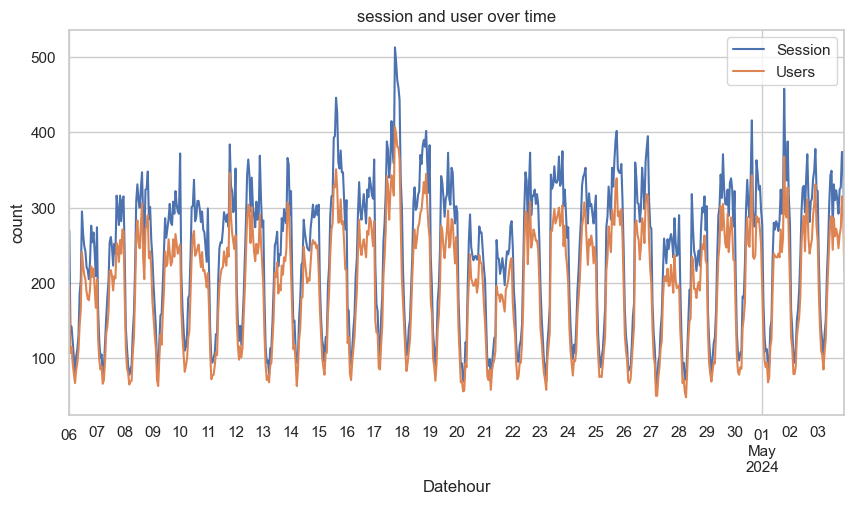

In [15]:
plt.figure(figsize=(10,5))
df.groupby("Datehour")[["Session","Users"]].sum().plot(ax=plt.gca())
plt.title("session and user over time")
plt.xlabel("Datehour")
plt.ylabel("count")
plt.savefig("Session_User_over_Time.png")
plt.show()

### Total Users by Channel

C:\Users\hp\AppData\Local\Temp\ipykernel_18104\3215392207.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Channel group",y="Users",estimator=np.sum,palette="viridis")


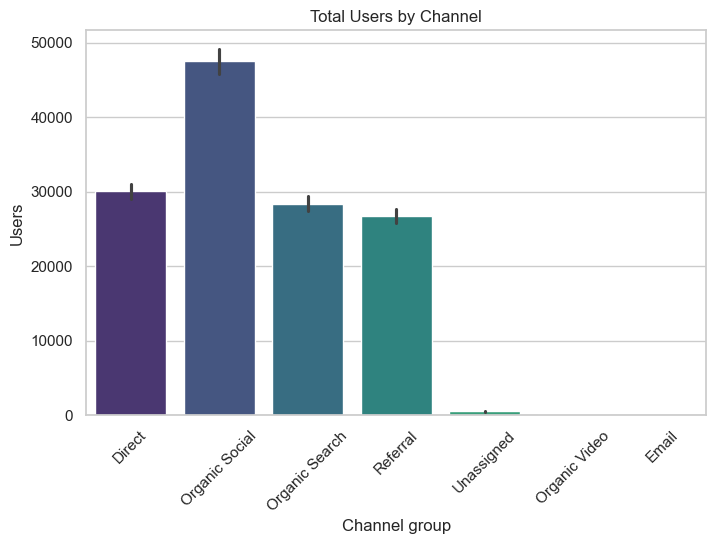

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Channel group",y="Users",estimator=np.sum,palette="viridis")
plt.title("Total Users by Channel")
plt.xticks(rotation=45)
plt.savefig("users_by_channel.png")
plt.show()

### Average Engagement Time by Channel

C:\Users\hp\AppData\Local\Temp\ipykernel_18104\2509453197.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Channel group",y="Average engagement time per session",estimator=np.mean,palette="magma")


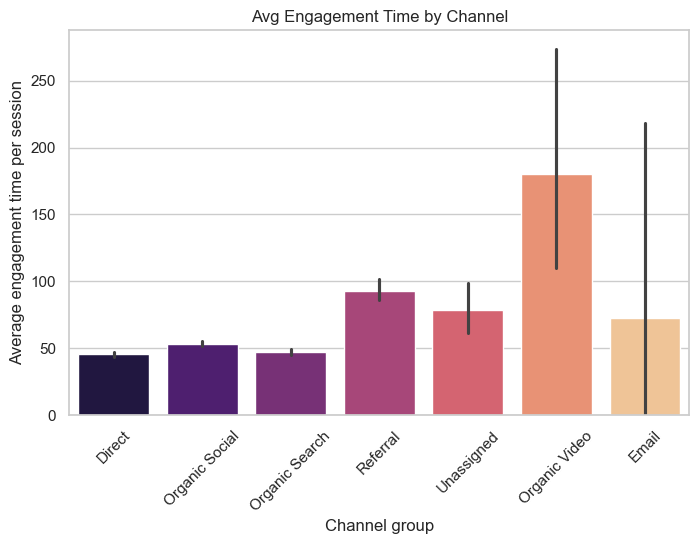

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Channel group",y="Average engagement time per session",estimator=np.mean,palette="magma")
plt.title("Avg Engagement Time by Channel")
plt.xticks(rotation=45)
plt.savefig("engage_time_by_channel.png")
plt.show()

### Engagement Rate Distribution by Channel

C:\Users\hp\AppData\Local\Temp\ipykernel_18104\4049636545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Channel group",y="Engagement rate",palette="coolwarm")


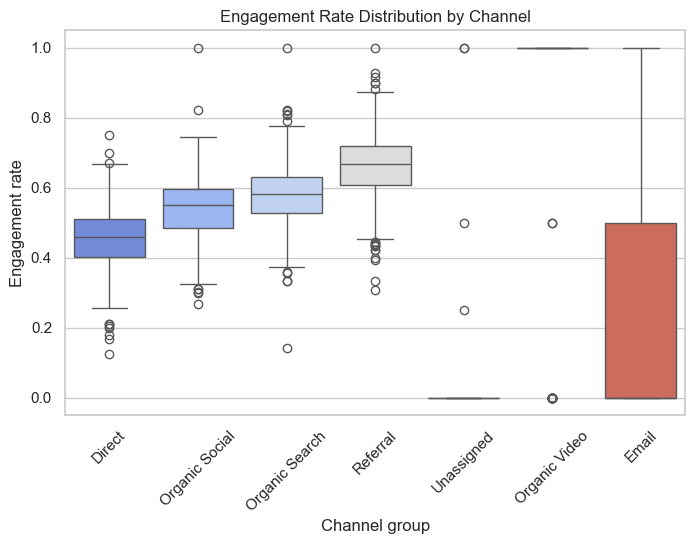

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Channel group",y="Engagement rate",palette="coolwarm")
plt.title("Engagement Rate Distribution by Channel")
plt.xticks(rotation=45)
plt.savefig("engage_rate_by_channel.png")
plt.show()


### Engaged vs Non Engaged Session

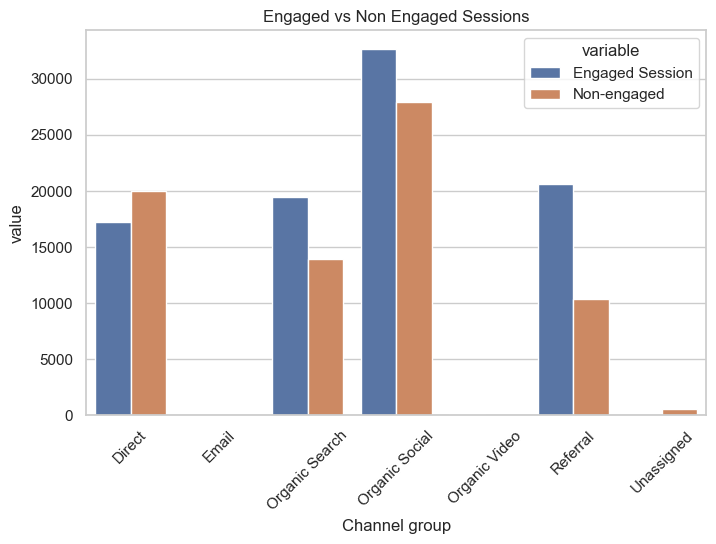

In [19]:
session_df=df.groupby("Channel group")[["Session","Engaged Session"]].sum().reset_index()
session_df["Non-engaged"]=session_df["Session"]-session_df["Engaged Session"]
session_df_melted=session_df.melt(id_vars="Channel group",value_vars=["Engaged Session","Non-engaged"])

plt.figure(figsize=(8,5))
sns.barplot(data=session_df_melted,x="Channel group",y="value",hue="variable")
plt.title("Engaged vs Non Engaged Sessions")
plt.xticks(rotation=45)
plt.savefig("engage_nonengage_session.png")
plt.show()



### Traffic by Hour and Channel

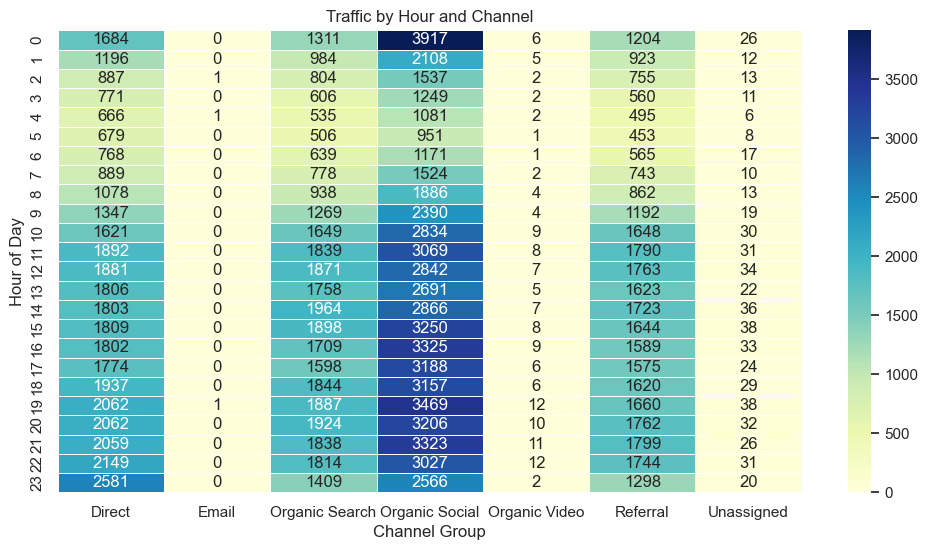

In [20]:
heatmap_data=df.groupby(["Hour","Channel group"])["Session"].sum().unstack().fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap="YlGnBu",linewidth=.5,annot=True,fmt=".0f")
plt.title("Traffic by Hour and Channel")
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day")
plt.savefig("heatmap.png")
plt.savefig("traffic.png")
plt.show()


### Engagement Rate vs Session Over Time

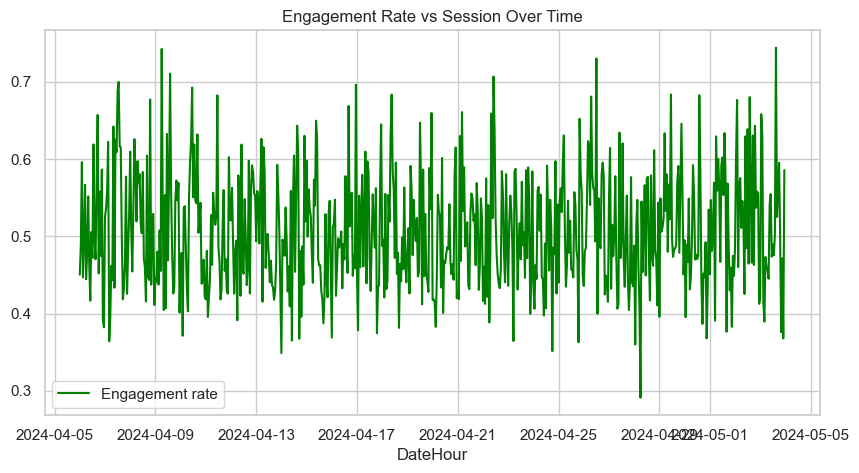

In [21]:
df_plot=df.groupby("Datehour")[["Engagement rate","Session"]].mean().reset_index()
plt.figure(figsize=(10,5))
plt.plot(df_plot["Datehour"],df_plot["Engagement rate"],label="Engagement rate",color="green")
plt.title("Engagement Rate vs Session Over Time")
plt.xlabel("DateHour")
plt.legend()
plt.savefig("engage_rate_session_overtime.png")
plt.show()

### saving cleaned dataset

In [22]:
df.to_csv("cleaned_web_data.csv")

### Summary

* It can be concluded that the **direct** and **organic social** traffic channels have been the biggest source of users and sessions on the site.

* As for **organic social**, it has proven the most productive engagement performance channel, implying that more engaged users are attracted to it.

* A peak period of visits has been identified in the evenings and at night, so this is the time one should consider posting on the site.

* There are some channels where traffic levels are high while engagement performance remains moderate, proving that high-quality traffic is more preferable than sheer volume.

* On average, visitors coming from highly-performing channels spent more time on the site than those from 
poorly-performing ones.

* A comparison of engaged vs not engaged sessions was particularly important for identifying the weak spots in user engagement performance.
